# Week 5 Assignment: Text Generation using RNN, LSTM and GRU

## Problem Statement
Design and implement a Deep Learning model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. Vanilla RNN  
2. LSTM  
3. GRU  

The notebook compares the models using training loss, accuracy, generated text quality, and training behavior.

## 1. Import Required Libraries
We use TensorFlow/Keras for sequence modeling and Matplotlib for performance visualization.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import os

print("TensorFlow Version:", tf.__version__)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

TensorFlow Version: 2.20.0


## 2. Load Text Corpus
A small custom corpus is used so the notebook runs easily in Google Colab.  
The corpus can be replaced with any larger text dataset such as stories, articles, poems, or chatbot text.

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies in text
gru is faster and simpler than lstm for many tasks
text generation models predict the next word in a sentence
machine learning models learn patterns from data
natural language processing helps computers understand human language
sequence models are useful for text speech and time series
neural networks can generate meaningful text after training
language models learn grammar structure and context from text
rnn processes text step by step using previous hidden states
lstm uses gates to remember important information for longer time
gru uses update and reset gates to control memory
deep learning improves performance in image and text applications
text generation is an important task in natural language processing
models can generate new sentences based on a seed text
contextual dependencies help models understand sentence meaning
training strategy affects accuracy loss and generated text quality
'''
print(corpus[:500])


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies in text
gru is faster and simpler than lstm for many tasks
text generation models predict the next word in a sentence
machine learning models learn patterns from data
natural language processing helps computers understand human language
sequence models are useful for text speech and time series
neural networks can generate meaningful text afte


## 3. Text Preprocessing and Tokenization
The text is converted into integer tokens.  
Then n-gram sequences are created for next-word prediction.

In [ ]:
# Convert text to lowercase and split into lines
corpus = corpus.lower().strip()
lines = [line.strip() for line in corpus.split('\n') if line.strip()]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(lines)

total_words = len(tokenizer.word_index) + 1
print("Vocabulary Size:", total_words)

# Create n-gram sequences
input_sequences = []

for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(2, len(token_list) + 1):
        n_gram_sequence = token_list[:i]
        input_sequences.append(n_gram_sequence)

max_sequence_len = max(len(seq) for seq in input_sequences)

# Pad sequences
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
)

# Features and target
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Maximum sequence length:", max_sequence_len)

Vocabulary Size: 98
Input shape: (140, 9)
Target shape: (140,)
Maximum sequence length: 10


## 4. Train-Test Split
For next-word prediction, the model learns from previous words and predicts the next word.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 112
Testing samples: 28


## 5. Helper Function to Build Models
The same structure is used for fair comparison.  
Only the recurrent layer changes: SimpleRNN, LSTM, or GRU.

In [ ]:
def build_sequence_model(model_type="RNN", embedding_dim=64, hidden_units=128, dropout_rate=0.2):
    model = Sequential()
    model.add(Embedding(input_dim=total_words, output_dim=embedding_dim, input_length=max_sequence_len - 1))

    if model_type == "RNN":
        model.add(SimpleRNN(hidden_units))
    elif model_type == "LSTM":
        model.add(LSTM(hidden_units))
    elif model_type == "GRU":
        model.add(GRU(hidden_units))
    else:
        raise ValueError("model_type must be RNN, LSTM, or GRU")

    model.add(Dropout(dropout_rate))
    model.add(Dense(total_words, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

## 6. Train Vanilla RNN Model
Vanilla RNN is the baseline sequence model.  
It works well for short sequences but may struggle with long-term dependencies.

In [ ]:
rnn_model = build_sequence_model("RNN")
rnn_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.0089 - loss: 4.5883 - val_accuracy: 0.0714 - val_loss: 4.6074
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0893 - loss: 4.4611 - val_accuracy: 0.0714 - val_loss: 4.6687
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0982 - loss: 4.3309 - val_accuracy: 0.0357 - val_loss: 4.8212
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0893 - loss: 4.1948 - val_accuracy: 0.0357 - val_loss: 4.9594
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1429 - loss: 4.0612 - val_accuracy: 0.0357 - val_loss: 5.0309
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1429 - loss: 3.9692 - val_accuracy: 0.0357 - val_loss: 5.0577


## 7. Train LSTM Model
LSTM uses input, forget, and output gates.  
It is better at learning long-term dependencies compared to vanilla RNN.

In [ ]:
lstm_model = build_sequence_model("LSTM")
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.0000e+00 - loss: 4.5849 - val_accuracy: 0.0357 - val_loss: 4.5855
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0714 - loss: 4.5636 - val_accuracy: 0.0357 - val_loss: 4.5923
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0714 - loss: 4.5316 - val_accuracy: 0.0000e+00 - val_loss: 4.6185
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0446 - loss: 4.4355 - val_accuracy: 0.0000e+00 - val_loss: 4.8794
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0268 - loss: 4.2591 - val_accuracy: 0.0714 - val_loss: 5.3937
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0446 - loss: 4.2432 - val_accuracy: 0.0357 - val_loss: 5.2834


## 8. Train GRU Model
GRU is similar to LSTM but has fewer gates.  
It is usually faster and can perform well on sequence tasks.

In [ ]:
gru_model = build_sequence_model("GRU")
gru_model.summary()

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.0179 - loss: 4.5852 - val_accuracy: 0.0000e+00 - val_loss: 4.5849
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1250 - loss: 4.5586 - val_accuracy: 0.0357 - val_loss: 4.5856
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1161 - loss: 4.5323 - val_accuracy: 0.0357 - val_loss: 4.5915
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1071 - loss: 4.4809 - val_accuracy: 0.0714 - val_loss: 4.6148
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0893 - loss: 4.3543 - val_accuracy: 0.0357 - val_loss: 4.9099
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0714 - loss: 4.2564 - val_accuracy: 0.0714 - val_loss: 5.1491


## 9. Model Evaluation
Now we evaluate all three models using loss and accuracy on the test data.

In [ ]:
results = []

for name, model in [("Vanilla RNN", rnn_model), ("LSTM", lstm_model), ("GRU", gru_model)]:
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    results.append({
        "Model": name,
        "Test Loss": round(loss, 4),
        "Test Accuracy": round(accuracy, 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Test Loss,Test Accuracy
0,Vanilla RNN,4.6074,0.0714
1,LSTM,4.5855,0.0357
2,GRU,4.5849,0.0000


## 10. Compare Training and Validation Loss
Lower loss generally means better learning.

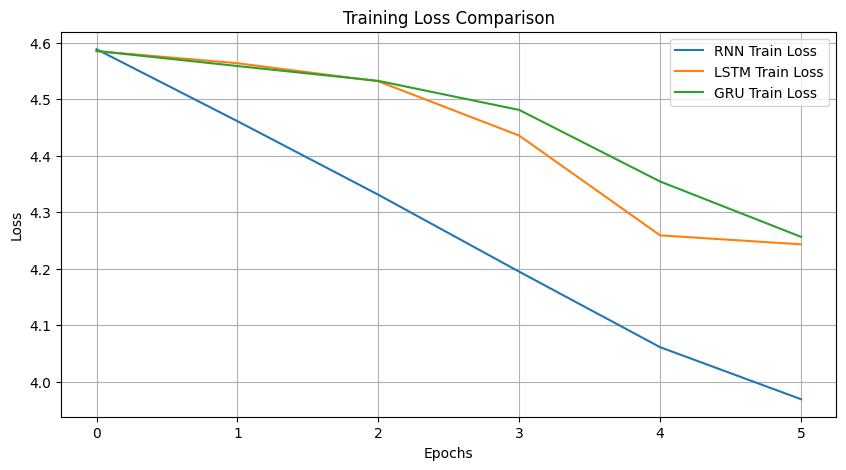

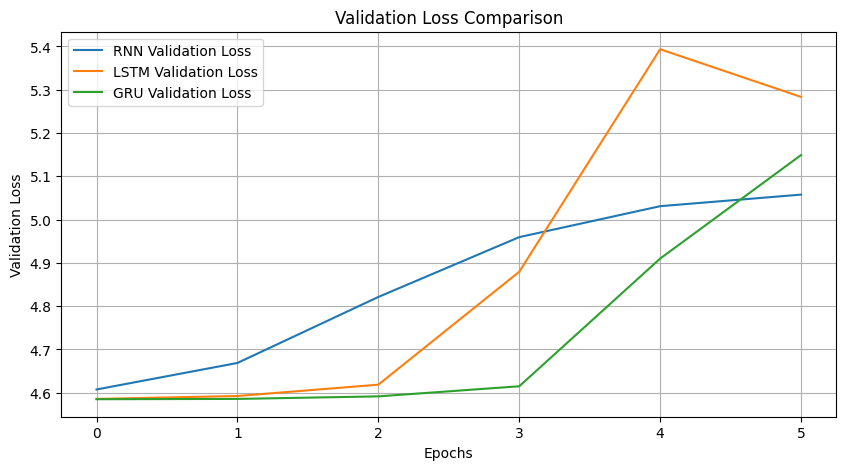

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history["loss"], label="RNN Train Loss")
plt.plot(lstm_history.history["loss"], label="LSTM Train Loss")
plt.plot(gru_history.history["loss"], label="GRU Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history["val_loss"], label="RNN Validation Loss")
plt.plot(lstm_history.history["val_loss"], label="LSTM Validation Loss")
plt.plot(gru_history.history["val_loss"], label="GRU Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

## 11. Text Generation Function
The function takes a seed text and predicts the next words one by one.

In [ ]:
def generate_text(model, seed_text, next_words=10, temperature=1.0):
    generated_text = seed_text.lower()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding="pre")

        predictions = model.predict(token_list, verbose=0)[0]

        # Temperature sampling
        predictions = np.asarray(predictions).astype("float64")
        predictions = np.log(predictions + 1e-8) / temperature
        exp_preds = np.exp(predictions)
        predictions = exp_preds / np.sum(exp_preds)

        predicted_index = np.random.choice(len(predictions), p=predictions)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        if output_word == "":
            break

        generated_text += " " + output_word

    return generated_text

## 12. Generate Text using RNN, LSTM and GRU
We use the same seed text for all models to compare output quality.

In [ ]:
seed_texts = ["deep learning", "text generation", "natural language"]

for seed in seed_texts:
    print("\nSeed Text:", seed)
    print("RNN :", generate_text(rnn_model, seed, next_words=8, temperature=0.8))
    print("LSTM:", generate_text(lstm_model, seed, next_words=8, temperature=0.8))
    print("GRU :", generate_text(gru_model, seed, next_words=8, temperature=0.8))


Seed Text: deep learning
RNN : deep learning gates affects previous human are are in sentences
LSTM: deep learning speech previous and loss applications generation remember remember
GRU : deep learning can next long time series are time to

Seed Text: text generation
RNN : text generation sequential update remember than computers models speech helps
LSTM: text generation language affects accuracy performance can lstm processes term
GRU : text generation neural tasks models contextual natural context generate the

Seed Text: natural language
RNN : natural language the data accuracy longer strategy based sequence help
LSTM: natural language is dependencies for training transforming processing applications gates
GRU : natural language understand word are improves learning generated reset gru


## 13. Architecture and Training Strategy Comparison

| Model | Strength | Limitation |
|---|---|---|
| Vanilla RNN | Simple and easy to understand | Struggles with long-term dependencies |
| LSTM | Better memory handling using gates | More parameters and slower training |
| GRU | Faster than LSTM with good memory handling | May be less powerful than LSTM for very complex text |

Training strategies used:
- Tokenization and n-gram sequence creation
- Embedding layer for word representation
- Early stopping to reduce overfitting
- Dropout for regularization
- Same train-test split for fair comparison

## 14. Final Observations

1. Vanilla RNN works as a baseline model but may not capture long-term context properly.
2. LSTM performs better when the text has longer dependencies because it uses memory gates.
3. GRU is simpler and faster than LSTM while still giving good performance.
4. Text generation quality improves when the corpus size and training epochs increase.
5. For real-world text generation, LSTM or GRU is usually preferred over vanilla RNN.

## 15. Conclusion

In this Week 5 assignment, I implemented text generation using Vanilla RNN, LSTM, and GRU.  
The models were trained to learn grammar, structure, and contextual dependencies from a text corpus.  
After comparing the performance, LSTM and GRU showed better sequence learning ability than vanilla RNN.

This assignment helped me understand recurrent neural networks, gated architectures, text preprocessing, sequence modeling, and next-word prediction.